# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

## 1.1. Importações e Download

In [1]:
from sklearn.metrics import accuracy_score

from src.data import load_mnist
from src.eda import resumo_shapes, distribuicao_classes
from src.visualize import plot_digito, plot_distribuicao, plot_grade_digitos
from src.preprocessing import split_treino_teste, normalizar_pixels
from src.models import (
    get_knn, buscar_melhor_knn,
    get_random_forest, buscar_melhor_random_forest,
    get_mlp, buscar_melhor_mlp,
)
from src.model_cache import obter_ou_buscar_modelo, salvar_metricas_modelo
from src.evaluation import (
    plot_matriz_confusao, calcular_metricas,
    montar_tabela_comparativa, gerar_conclusao_tecnica,
)

In [2]:
# Baixando o MNIST oficial do OpenML
print("Baixando o dataset MNIST...")
X, y = load_mnist()
print("Download do dataset MNIST finalizado!")

Baixando o dataset MNIST...
Download do dataset MNIST finalizado!


## 1.2. Dimensionalidade das Matrizes (X e y)

In [3]:
# Mostra um número aleatório do dataset
X[700] 

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,  98, 224,  42,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  3

In [4]:
# Mostra os resultados do dataset (rótulos/targets das imgs)
y

array([5, 0, 4, ..., 4, 5, 6], dtype=uint8)

In [5]:
resumo_shapes(X, y)

Formato de X (amostras, pixels por imagem): (70000, 784)
Formato de y (rótulos): (70000,)
Classes únicas existentes: [0 1 2 3 4 5 6 7 8 9]


A escala de intensidade dos pixels em imagens em tons de cinza varia de 0 a 255, onde o valor 0 representa a cor preta e o valor 255 representa a cor branca. Os valores intermediários representam diferentes tons de cinza, sendo que quanto maior o valor, mais claro é o pixel. No conjunto de dados MNIST, cada imagem possui dimensões de 28 × 28 pixels, totalizando 784 pixels por imagem, pois 28 * 28 = 784. Inicialmente, a imagem é representada como uma matriz bidimensional (28 × 28), em que cada posição contém o valor de intensidade de um pixel. Para utilizar a imagem em determinados algoritmos de aprendizado de máquina, essa matriz pode ser transformada em um vetor unidimensional por meio do processo chamado flattening (achatamento). Dessa forma, os 784 pixels passam a ser representados como 784 features, sendo que cada feature corresponde à intensidade de um determinado pixel, com valores entre 0 e 255.

![Explicação MNIST](images/explicacao_mnist.png)

## 1.3. Distribuição das Classes

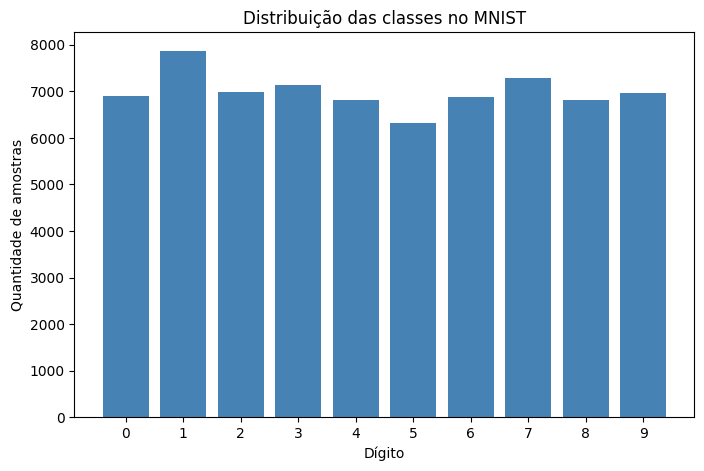

In [6]:
# Conta quantas amostras existem de cada dígito 
classes, contagens = distribuicao_classes(y)
plot_distribuicao(classes, contagens)

## 1.4. Grade Visual

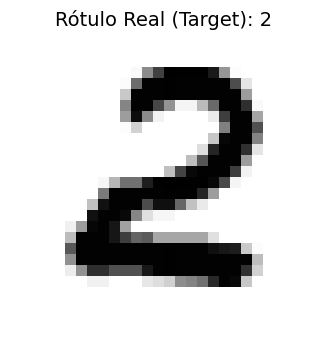

In [7]:
# Visualiuzando uma imagem do dataset
indice = 65643
plot_digito(X, y, indice)

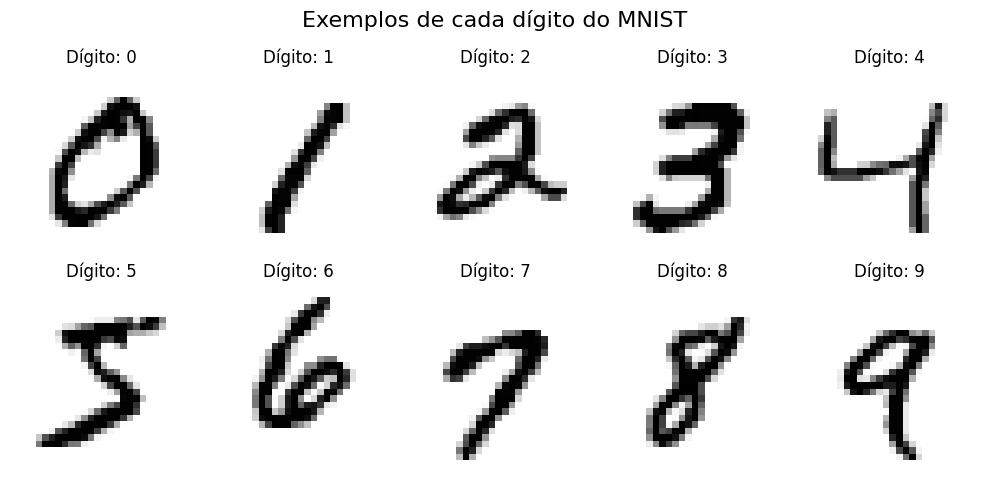

In [8]:
plot_grade_digitos(X, y)

# Fase 2: Divisão dos Dados

## 2.1. Split Treino (80%) e Teste (20%)

In [9]:
# Divide em 80% treino e 20% teste, de forma estratificada por classe
X_train, X_test, y_train, y_test = split_treino_teste(X, y, test_size=0.2, random_state=42)

print("Formato de X_train:", X_train.shape)
print("Formato de X_test:", X_test.shape)
print("Formato de y_train:", y_train.shape)
print("Formato de y_test:", y_test.shape)

Formato de X_train: (56000, 784)
Formato de X_test: (14000, 784)
Formato de y_train: (56000,)
Formato de y_test: (14000,)


## 2.2. Normalização dos Pixels

In [10]:
# Redimensiona os valores de pixel de [0, 255] para a escala [0.0, 1.0]
X_train, X_test = normalizar_pixels(X_train, X_test)

print("Valor mínimo em X_train:", X_train.min())
print("Valor máximo em X_train:", X_train.max())

Valor mínimo em X_train: 0.0
Valor máximo em X_train: 1.0


**Distâncias métricas:** Modelos que calculam distâncias geométricas (como a Euclidiana) falham se os atributos tiverem escalas altas, pois pixels maiores dominam o cálculo da proximidade entre os dígitos.

**Convergência :** Algoritmos baseados em gradiente ajustam seus pesos buscando o menor erro possível. Valores uniformes entre `0.0` e `1.0` estabilizam a superfície de aprendizado, evitando saltos desproporcionais e permitindo que o modelo **converja muito mais rápido** para o resultado correto.

# Fase 3: Implementação e Treinamento dos 3 Modelos

Os melhores hiperparâmetros de cada modelo, encontrados via `GridSearchCV`, são salvos em `config/melhores_hiperparametros.json`. Ao rodar o notebook novamente, cada modelo é recriado direto a partir desses hiperparâmetros salvos (sem repetir a busca).

## 3.1. KNN (K-Nearest Neighbors)

**Hiperparâmetro `n_neighbors`:** quantidade de vizinhos mais próximos consultados para classificar uma imagem;

**Hiperparâmetro `weights`:** forma de ponderar o voto dos vizinhos. 'uniform' dá peso
      igual a todos; 'distance' dá mais peso aos vizinhos mais próximos.

Abaixo foi utilizado `GridSearchCV` para testar várias combinações de `n_neighbors` e `weights` com validação cruzada e escolher automaticamente a combinação com melhor acurácia média nos dados de treino.

In [11]:
buscar_novamente_knn = False  # True para rodar o GridSearchCV 

knn, melhores_params_knn, tempo_treino_knn = obter_ou_buscar_modelo(
    'knn', get_knn, buscar_melhor_knn, X_train, y_train,
    buscar_novamente=buscar_novamente_knn,
)
print("Melhores hiperparâmetros do KNN:", melhores_params_knn)

y_pred_knn = knn.predict(X_test)
print("Acurácia do KNN no conjunto de teste:", accuracy_score(y_test, y_pred_knn))
print("Tempo de treino do KNN (s):", tempo_treino_knn)

Melhores hiperparâmetros do KNN: {'n_neighbors': 6, 'weights': 'distance'}
Acurácia do KNN no conjunto de teste: 0.9708571428571429
Tempo de treino do KNN (s): 0.006615161895751953


## 3.2. Random Forest

**Hiperparâmetro `n_estimators`:** número de árvores de decisão no ensemble;

**Hiperparâmetro `max_depth`:** profundidade máxima de cada árvore.

Abaixo foi utilizado o `GridSearchCV` para testar várias combinações de `n_estimators` e `max_depth` com validação cruzada e escolher automaticamente a combinação com melhor acurácia média nos dados de treino.

In [12]:
buscar_novamente_rf = False  # True para rodar o GridSearchCV 

rf, melhores_params_rf, tempo_treino_rf = obter_ou_buscar_modelo(
    'random_forest', get_random_forest, buscar_melhor_random_forest, X_train, y_train,
    buscar_novamente=buscar_novamente_rf,
)
print("Melhores hiperparâmetros da Random Forest:", melhores_params_rf)

y_pred_rf = rf.predict(X_test)
print("Acurácia do Random Forest no conjunto de teste:", accuracy_score(y_test, y_pred_rf))
print("Tempo de treino da Random Forest (s):", tempo_treino_rf)

Melhores hiperparâmetros da Random Forest: {'max_depth': None, 'n_estimators': 300}
Acurácia do Random Forest no conjunto de teste: 0.9680714285714286
Tempo de treino da Random Forest (s): 44.837165117263794


## 3.3. MLP (Perceptron Multicamadas)

**Hiperparâmetro `hidden_layer_sizes`:** quantidade de neurônios em cada camada oculta;

**Hiperparâmetro `learning_rate_init`:** taxa de aprendizado inicial do otimizador baseado em gradiente.

Abaixo foi utilizado `GridSearchCV` para testar várias combinações de `hidden_layer_sizes` e `learning_rate_init` com validação cruzada e escolher automaticamente a combinação com melhor acurácia média nos dados de treino.

In [13]:
buscar_novamente_mlp = False  # True para rodar o GridSearchCV 

mlp, melhores_params_mlp, tempo_treino_mlp = obter_ou_buscar_modelo(
    'mlp', get_mlp, buscar_melhor_mlp, X_train, y_train,
    buscar_novamente=buscar_novamente_mlp,
)
print("Melhores hiperparâmetros do MLP:", melhores_params_mlp)

y_pred_mlp = mlp.predict(X_test)
print("Acurácia do MLP no conjunto de teste:", accuracy_score(y_test, y_pred_mlp))
print("Tempo de treino do MLP (s):", tempo_treino_mlp)

/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Melhores hiperparâmetros do MLP: {'hidden_layer_sizes': [128, 64], 'learning_rate_init': 0.001}
Acurácia do MLP no conjunto de teste: 0.9803571428571428
Tempo de treino do MLP (s): 8.95517110824585


/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jenifer/Documents/SCTEC-Mini-Projeto-MD2/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


# Fase 4: Avaliação Comparativa de Desempenho

## 4.1. Matrizes de Confusão

OBS: A diagonal principal mostra os acertos por dígito, e as células fora da diagonal mostram para qual dígito cada erro foi classificado.

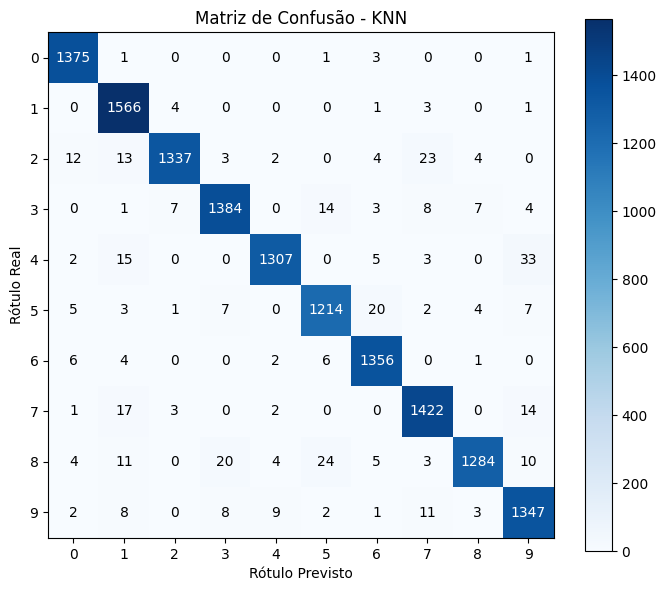

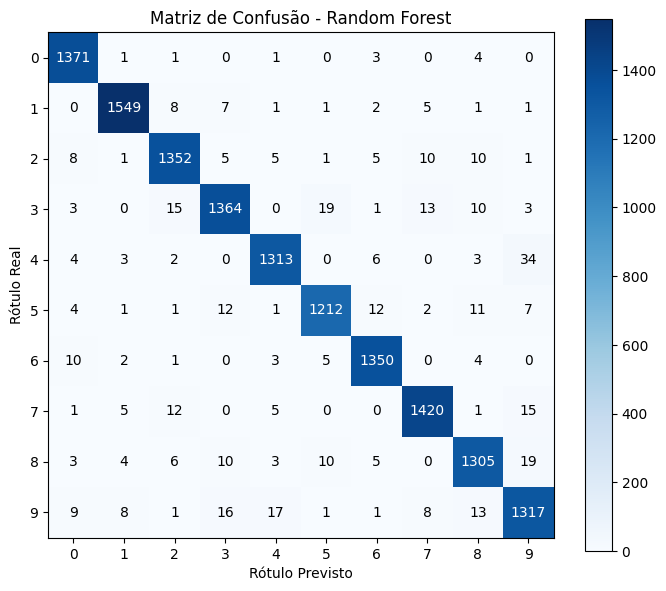

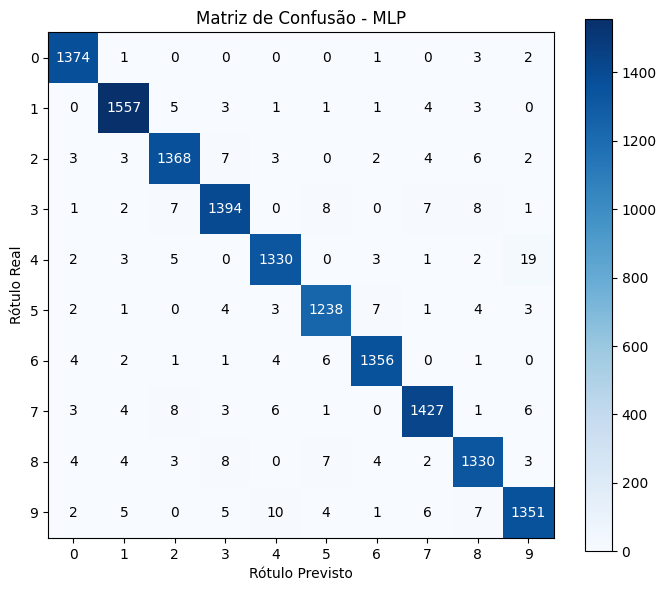

In [14]:
matriz_knn = plot_matriz_confusao(y_test, y_pred_knn, "KNN")
matriz_rf  = plot_matriz_confusao(y_test, y_pred_rf, "Random Forest")
matriz_mlp = plot_matriz_confusao(y_test, y_pred_mlp, "MLP")

## 4.2. Tabela Comparativa de Métricas

Para cada modelo, foram calculadas as métricas:
- Acurácia Global (Accuracy)
- Precisão Média Ponderada (Precision)
- Revocação/Sensibilidade Média Ponderada (Recall)
- Fl-Score Ponderado (Fl-Score)

Também foi calculado o tempo de treino de cada modelo.

In [15]:
metricas_knn = calcular_metricas(y_test, y_pred_knn, "KNN", tempo_treino=tempo_treino_knn)
metricas_rf  = calcular_metricas(y_test, y_pred_rf, "Random Forest", tempo_treino=tempo_treino_rf)
metricas_mlp = calcular_metricas(y_test, y_pred_mlp, "MLP", tempo_treino=tempo_treino_mlp)

salvar_metricas_modelo(metricas_knn, 'knn')
salvar_metricas_modelo(metricas_rf, 'random_forest')
salvar_metricas_modelo(metricas_mlp, 'mlp')

tabela_comparativa = montar_tabela_comparativa([metricas_knn, metricas_rf, metricas_mlp])
tabela_comparativa

,Acurácia,Precisão (ponderada),Revocação (ponderada),F1-Score (ponderado),Tempo de Treino (s)
Modelo,,,,,
KNN,0.9709,0.9711,0.9709,0.9708,0.0066
Random Forest,0.9681,0.9681,0.9681,0.9681,44.8372
MLP,0.9804,0.9803,0.9804,0.9803,8.9552


## 4.3. Conclusão Técnica

In [16]:
previsoes = {
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf,
    "MLP": y_pred_mlp,
}

print(gerar_conclusao_tecnica(tabela_comparativa, y_test, previsoes))

Confusão mais frequente por modelo:
- KNN: dígito real 4 classificado como 9 em 33 casos.
- Random Forest: dígito real 4 classificado como 9 em 34 casos.
- MLP: dígito real 4 classificado como 9 em 19 casos.

Menor custo computacional de treino: KNN, treinado em 0.01s.


O MLP (Perceptron Multicamadas)** obteve melhor performance em todas as métricas.

* **KNN:** Menor tempo de treino absoluto ($\approx 0,0071\text{ s}$), excelente acurácia ($97,09\%$) e melhor relação custo-benefício para máxima velocidade.
* **MLP:** Maior acurácia global ($\approx 98,04\%$) e melhor equilíbrio geral nas métricas ponderadas, com tempo de treino intermediário ($\approx 9,01\text{ s}$).
* **Random Forest:** Maior custo computacional de treinamento ($\approx 45,38\text{ s}$) devido às árvores de decisão, mas entregou a menor acurácia do trio ($96,81\%$).

O MLP justifica-se pelo ganho em acurácia, enquanto o KNN destaca-se pela extrema leveza operacional com perda mínima de desempenho.